# Heston Stochastic Volatility Model

The Black–Scholes model assumes that the volatility of the underlying asset is constant throughout the life of the option. In practice, however, market volatility evolves over time and exhibits features such as volatility clustering, mean reversion, and the leverage effect. The Heston model addresses these limitations by treating the asset variance as a stochastic process.

Under the risk-neutral measure, the stock price and variance evolve according to

$$
dS_t = rS_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S,
$$

$$
dv_t = \kappa(\theta-v_t)\,dt + \sigma\sqrt{v_t}\,dW_t^v,
$$

where the two Brownian motions satisfy

$$
dW_t^S\,dW_t^v = \rho\,dt.
$$

The model parameters are:

- **`v0`**: initial variance of the underlying asset.
- **`kappa`**: speed of mean reversion of the variance process.
- **`theta`**: long-run mean variance.
- **`sigma`**: volatility of volatility (vol-of-vol), controlling the randomness of the variance process.
- **`rho`**: correlation between the stock price and variance shocks. For equity markets this parameter is typically negative, allowing the model to capture the observed implied volatility skew.
- **`lambd`**: market price of volatility risk, which adjusts the variance dynamics under the risk-neutral measure.

Unlike the Black–Scholes model, the Heston model does not produce option prices by assuming a constant volatility. Instead, it models the joint dynamics of the stock price and its variance, leading to a more realistic description of market behavior while remaining tractable for pricing European options through characteristic-function methods.

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import minimize
from datetime import datetime as dt

from scipy.stats import norm
from scipy.optimize import brentq

from utils import vega, implied_vol

import pickle

import warnings
warnings.filterwarnings("ignore")

## 1. Load and prepare option data

In [ ]:
df = pd.read_csv('clean_iv_surface_input.csv')
df['date'] = pd.to_datetime(df['date'])
df['expiry'] = pd.to_datetime(df['expiry'])
df['k'] = df['log_moneyness']

df["vega"] = vega(
    df["underlying_price"],
    df["strike"],
    df["T"],
    df["IV"]
)

df = df[df['option_type'] == 'call']

dates = sorted(df['date'].unique())

## 2. Heston option pricing

We implement the Heston stochastic volatility model for pricing European options. Rather than solving the pricing PDE directly, Heston derives a semi-closed-form solution using characteristic functions. The resulting option price has a structure similar to the Black–Scholes formula but replaces the normal distribution with probabilities recovered through Fourier inversion of the characteristic function.

 $$ C(S_0, K, T) = S P_1 - K e^{-rT}P_2$$
 where
 - $P_1$ is the delta of the European call option and
 - $P_2$ is the conditional risk neutral probability that the asset price will be greater than $K$ at maturity.

 Both probabilities $P_{1,2}$ also satisfy Garman's PDE provided that characteristic functions $\phi_1, \phi_2$ are known. The terms $P_{1,2}$ are defined via the inverse Fourier transformation. 

$$X = ln(S)$$

$$P_j = \frac{1}{2} + \frac{1}{\pi} \int_{0}^{\infty} Re[ \frac{e^{i\varphi ln(K)}\phi_j(X_0, K: \varphi)}{i \varphi}] d\varphi, j\in \{1,2\}$$


Heston assumes the characteristic functions $\phi_1, \phi_2$ having the form:
$$ \phi_j = e^{C(\tau;\varphi)+D(\tau;\varphi)v + i \varphi X}$$

With semianalytical solution:
$$ C(\tau;\varphi) = r\varphi i \tau + \frac{a}{\sigma^2}[(b_j - \rho\sigma\varphi i+d)\tau - 2ln(\frac{1-ge^{d\tau}}{1-g})]  $$
$$ D(\tau;\varphi) = \frac{b_j - \rho\sigma\varphi i}{\sigma^2}[\frac{1-e^{d\tau}}{1-ge^d\tau}]$$

where

- $g = \frac{b_j - \rho\sigma\varphi i + d}{b_j - \rho\sigma\varphi i - d}$
- $d = \sqrt{(\rho\sigma\varphi i - b_j)^2 - \sigma^2(2u_j\varphi i - \varphi^2)}$
- $u_1 = 0.5$, $u_2 = -0.5$
- $a= \kappa \theta$
- $b_1 = \kappa + \lambda = \rho\sigma$
- $b_2 = \kappa + \lambda$ 

In [6]:
def heston_option(S0, K, r, t, kappa, v0, xi, rho, theta, option_type = "call"):
    """
    Price of a call option under Heston model
    
    Parameters:
    - S0 (float): Initial stock price
    - K (float): Strike Price
    - r (float): Risk-free interest rate
    - t (float): Time-to-expiration (in years)
    - v0 (float): Initial variance
    - kappa (float): Rate of mean reversion of variance (1 to 5)
    - theta (float): Long-run variance
    - xi (float): Volatility of volatility (.2 to 1)
    - rho (float): Correlation between Brownian motions (-.9 to -.2)
    - option_type (string): 'call' for call and 'put' for put

    Returns:
    - price (float): Option price
    """

    def integrand(phi, Pnum):
        i = complex(0, 1)
        u = 0.5 if Pnum == 1 else -0.5
        b = kappa - rho * xi if Pnum == 1 else kappa
        a = kappa * theta
        d = np.sqrt((rho * xi * phi * i - b)**2 - xi**2 * (2 * u * phi * i - phi**2))
        g = (b - rho * xi * phi * i + d) / (b - rho * xi * phi * i - d)
        
        exp1 = np.exp(i * phi * np.log(S0 / K))
        C = r * phi * i * t + a / xi**2 * ((b - rho * xi * phi * i + d) * t - 2 * np.log((1 - g * np.exp(d * t)) / (1 - g)))
        D = (b - rho * xi * phi * i + d) / xi**2 * ((1 - np.exp(d * t)) / (1 - g * np.exp(d * t)))
        f = exp1 * np.exp(C + D * v0)
        return np.real(f / (phi * i))

    P1 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 1), 0, 100)[0]
    P2 = 0.5 + (1 / np.pi) * quad(lambda phi: integrand(phi, 2), 0, 100)[0]
    call_price = S0 * P1 - K * np.exp(-r * t) * P2
    put_price = call_price - S0 + K * np.exp(-r * t)
    
    if option_type == 'call':
        return call_price
    
    if option_type == 'put':
        return put_price


## 3. Calibration

In [7]:
###Calibrate Heston model to option data using gradient descent

### We will calibrate all 5 parameters

### Goal will be to find values of the 5 parameters minimizing the following function

def objective(params, data, r):
    kappa, v0, xi, rho, theta = params
    
    error = 0
    for _, row in data.iterrows():
        model_price = heston_option(
            S0=row['underlying_price'],
            K=row['strike'],
            r=r,
            t=row['T'],
            v0=v0,
            kappa=kappa,
            theta=theta,
            xi=xi,
            rho=rho,
            option_type = row['option_type']
        )
        market_price = row['market_price']
        error += (model_price - market_price) ** 2
        
    return error / len(data)

In [13]:
heston_params = {}


for date in dates:

    date_df = df[df['date'] == date].copy()

    #need to create a reasonable first guess and set bounds for our model calibration

    initial_guess = [3, .4**2, .6, -.6,.4**2]  #kappa, v0, xi, rho, theta
    bounds = [(.01, 8), (.1**2, .9**2), (.01, 2), (-1,-0.01), (.1**2, .9**2)] 

    r = .039


    result = minimize(
        objective,
        initial_guess,
        args=(date_df, r),
        bounds=bounds,
        method='L-BFGS-B',
        options={
            'disp': False,
            'maxiter': 20,       
            'ftol': 1e-4,         
            'gtol': 1e-4          
        }
    )

    calibrated_params = result.x

    heston_params[date] = calibrated_params

In [ ]:
# Save heston_params dict

# Save parameters

with open("heston_params.pkl", "wb") as f:
    pickle.dump(heston_params, f)

In [10]:
with open("heston_params.pkl", "rb" ) as f:
    heston_params = pickle.load(f)

## 4. Heston - Implied Volatility Function

In [11]:
def heston_iv(date, S, K, t, r = 0.04):
    
    kappa, v0, xi, rho, theta = heston_params[date]

    price = heston_option(S, K, t, r, kappa, v0, xi, rho, theta)

    iv = implied_vol(price, S, K, t, r,  q = 0, option_type = "call")

    return iv


## 5. Construct Heston-implied volatility surface 

In [ ]:
day = dates[2]

day_df = df[df['date'] == day].copy()

params = heston_params[day]

kappa, v0, xi,rho,theta = params


day_df["heston_iv"] = day_df.apply(
    lambda row: heston_iv(
        date = day,
        S = row["underlying_price"],
        K = row["strike"],
        t = row["T"],
        r = 0.04
    ),
    axis = 1
)

day_df[["IV", "heston_iv"]].head()

,IV,heston_iv
59,0.635983,0.873198
61,0.981360,0.856625
65,0.701543,0.828544
68,0.669601,0.816082
71,0.663273,0.803030
...,...,...
7186,0.262849,0.090539
7207,0.262814,0.087164
7228,0.257668,0.083859
7249,0.252992,0.080934


In [14]:
def plot_surface_with_market(df, column, title):

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_trisurf(
        df["k"],
        df["T"],
        df[column],
        cmap="viridis",
        alpha=0.7
    )

    ax.scatter(
        df["k"],
        df["T"],
        df["IV"],
        color="red",
        s=20,
        label="Market"
    )

    ax.set_xlabel("Log-moneyness")
    ax.set_ylabel("T")
    ax.set_zlabel("IV")
    ax.legend()
    ax.set_title(title)

    plt.show()

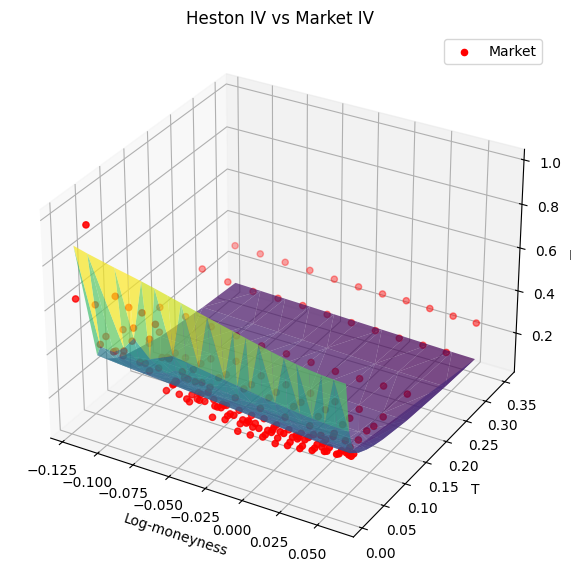

In [32]:
plot_surface_with_market(day_df, "heston_iv", "Heston IV vs Market IV")

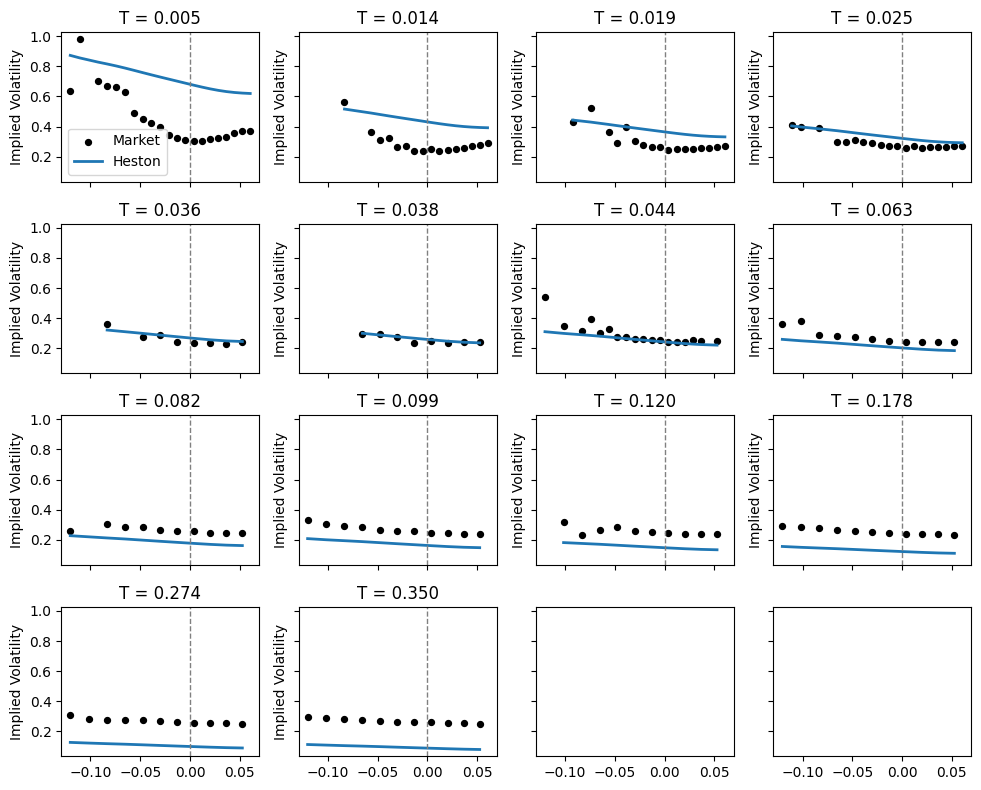

In [33]:
maturities = sorted(day_df["T"].unique())

fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, T in zip(axes, maturities):

    temp = (
        day_df[day_df["T"] == T]
        .sort_values("k")
    )

    ax.scatter(
        temp["k"],
        temp["IV"],
        color="black",
        s=18,
        label="Market"
    )

    ax.plot(
        temp["k"],
        temp["heston_iv"],
        lw=2,
        label="Heston"
    )

    ax.set_title(f"T = {T:.3f}")

    ax.set_ylabel("Implied Volatility")

    ax.axvline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

axes[0].legend()


plt.tight_layout()
plt.show()

## 5. Calibration Performance

In [34]:
rmse = {}
rmse_vega = {}
bucket_errors = {}

for date in dates:

    date_df = df[df["date"] == date][["k", "strike", "T", "underlying_price", "IV", "vega"]].copy()

    date_df["heston_iv"] = date_df.apply(
        lambda row: heston_iv(
            date = dates[2],
            S = row["underlying_price"],
            K = row["strike"],
            t = row["T"],
            r = 0.04
        ),
        axis = 1
    )


    err2 = (date_df["heston_iv"] - date_df["IV"]) ** 2

    rmse[date] = np.sqrt(np.mean(err2))

    rmse_vega[date] = np.sqrt(
        np.average(err2, weights=date_df["vega"])
    )

    date_df["moneyness_bucket"] = pd.cut(
        date_df["k"].abs(),
        bins=[0, 0.05, 0.1, np.inf],
        labels=["ATM", "Near-wing", "Far-wing"]
    )

    bucket_rmse = date_df.groupby("moneyness_bucket").apply(
        lambda x: np.sqrt(np.mean((x["heston_iv"] - x["IV"]) ** 2))
    )

    bucket_errors[date] = bucket_rmse

results_df = pd.DataFrame({
    "date": rmse.keys(),
    "rmse": rmse.values(),
    "vega_rmse": rmse_vega.values(),
})

bucket_df = (
    pd.DataFrame(bucket_errors)
      .T
      .reset_index()
      .rename(columns={"index": "date"})
)

results_df = results_df.merge(bucket_df, on="date", how="left")

results_df.drop(columns="date").mean()

rmse         0.181899
vega_rmse    0.138698
ATM          0.185548
Near-wing    0.146020
Far-wing     0.176376
dtype: float64